# Customer Segmentation Using RFM Analysis and KMeans Clustering

# The objective of this project is to segment customers based on purchasing behavior and demographics using RFM analysis and KMeans clustering. 
# The analysis helps identify VIP, premium, regular, and inactive customers for targeted business strategies.

In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_csv('online_retail.csv')

In [3]:
# Data Understanding

print(df.shape, '\n')
print(df.dtypes, '\n')
print(df.isna().sum())

(541909, 8) 

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object 

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [4]:
# Data Cleaning

df['Description'] = df['Description'].fillna('None')
df = df.dropna(subset=['CustomerID'])
df.isna().sum()
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

df.drop_duplicates(keep='first', inplace=True)
print('duplicates: ', df.duplicated().sum(), '\n')

df['Revenue'] = df['Quantity']*df['UnitPrice']
print(list(df.columns))

duplicates:  0 

['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'Revenue']


In [5]:
## Feature Engineering

# Created new business metrics such as:
# - Revenue
# - Total Orders
# - Total Quantity
# - Average Order Value
# - Average Order Quantity

# These features help analyze customer purchasing behavior effectively.

In [6]:
customer_df = df.groupby('CustomerID').agg({
    'Revenue': 'sum',
    'InvoiceNo': 'nunique',
    'Quantity': 'sum'
}).reset_index()

customer_df.columns = ['CustomerID','TotalRevenue', 'TotalOrders', 'TotalQuantity']
customer_df['AvgOrderValue'] = customer_df['TotalRevenue']/customer_df['TotalOrders']
customer_df['AvgOrderQuantity'] = customer_df['TotalQuantity']/customer_df['TotalOrders']
print(customer_df.iloc[customer_df['TotalRevenue'].idxmax()], '\n')
print(list(customer_df.columns))

CustomerID           14646.000000
TotalRevenue        280206.020000
TotalOrders             73.000000
TotalQuantity       196915.000000
AvgOrderValue         3838.438630
AvgOrderQuantity      2697.465753
Name: 1689, dtype: float64 

['CustomerID', 'TotalRevenue', 'TotalOrders', 'TotalQuantity', 'AvgOrderValue', 'AvgOrderQuantity']


In [7]:
country_df = df.groupby('CustomerID')['Country'].first().reset_index()
if 'Country' in customer_df.columns:
    customer_df = customer_df.drop(columns=['Country'])
customer_df = customer_df.merge(
    country_df,
    on='CustomerID',
    how='left'
)
print('Number of Countries: ', customer_df['Country'].nunique())
print(customer_df['Country'].unique())

Number of Countries:  37
['United Kingdom' 'Iceland' 'Finland' 'Italy' 'Norway' 'Bahrain' 'Spain'
 'Portugal' 'Switzerland' 'Austria' 'Cyprus' 'Belgium' 'Unspecified'
 'Denmark' 'Australia' 'France' 'Germany' 'RSA' 'Greece' 'Sweden' 'Israel'
 'USA' 'Saudi Arabia' 'Poland' 'United Arab Emirates' 'Singapore' 'Japan'
 'Netherlands' 'Lebanon' 'Brazil' 'Czech Republic' 'EIRE'
 'Channel Islands' 'European Community' 'Lithuania' 'Canada' 'Malta']


In [8]:
## RFM Analysis

# Applied RFM (Recency, Frequency, Monetary) analysis to measure:
# - how recently customers purchased
# - how frequently they purchase
# - how much revenue they generate

# RFM analysis is widely used in customer analytics and Customer-Relationship Management systems.

In [9]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
latest_date = df['InvoiceDate'].max()
recency_df = df.groupby('CustomerID').agg({
    'InvoiceDate' : lambda x : (latest_date - x.max()).days
}).reset_index()
recency_df.columns = ['CustomerID', 'Recency']

if 'Recency' in customer_df.columns:
    customer_df = customer_df.drop(columns=['Recency'])
customer_df = customer_df.merge(
    recency_df,
    on='CustomerID',
    how='left'
)

print(customer_df['Recency'].head(5))

0    325
1      1
2     74
3     18
4    309
Name: Recency, dtype: int64


In [10]:
print(list(customer_df.columns))

['CustomerID', 'TotalRevenue', 'TotalOrders', 'TotalQuantity', 'AvgOrderValue', 'AvgOrderQuantity', 'Country', 'Recency']


In [11]:
features = customer_df[[
    'Recency',
    'TotalRevenue',
    'TotalOrders',
    'TotalQuantity',
    'AvgOrderValue',
    'AvgOrderQuantity'
]]
print(list(features))

['Recency', 'TotalRevenue', 'TotalOrders', 'TotalQuantity', 'AvgOrderValue', 'AvgOrderQuantity']


In [12]:
## Feature Scaling

# Applied StandardScaler to normalize feature values before clustering. 
# Scaling prevents features with larger magnitudes from dominating the clustering process.

features = np.log1p(features)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
print(scaled_features)

[[ 1.40989446e+00  3.70771630e+00 -9.55214264e-01  3.81894910e+00
   7.52280682e+00  6.83277102e+00]
 [-2.14649825e+00  1.41490344e+00  1.07442519e+00  1.33269016e+00
   1.04416007e+00  9.11225581e-01]
 [ 3.83971280e-01  7.20024280e-01  3.86304448e-01  1.29711755e+00
   6.22311699e-01  1.47531408e+00]
 ...
 [-1.17860486e+00 -1.11333158e+00 -3.61582777e-01 -9.75444254e-01
  -1.53723592e+00 -1.19504650e+00]
 [-1.66255156e+00  8.22812169e-01  2.17800394e+00  8.99435616e-01
  -1.05628556e+00 -6.51274404e-01]
 [-4.42204601e-03  7.37525725e-01  5.96054655e-02  1.01314684e+00
   1.03698980e+00  1.36298712e+00]]


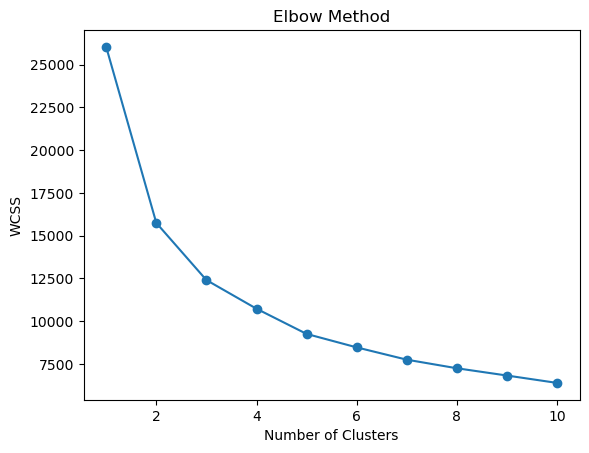

In [13]:
## Determining Optimal Number of Clusters

# Used the Elbow Method to identify the optimal number of customer clusters by analyzing WCSS (Within-Cluster Sum of Squares).

wcss = []
for k in range(1,11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(scaled_features)
    wcss.append(model.inertia_)
    
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

# Choose k=4

In [14]:
## Customer Segmentation Using KMeans

# Applied KMeans clustering to group customers based on purchasing behavior and RFM metrics.

kmeans = KMeans(n_clusters=4, random_state=42)
customer_df['Cluster'] = kmeans.fit_predict(scaled_features)
customer_df.head(10)

,CustomerID,TotalRevenue,TotalOrders,TotalQuantity,AvgOrderValue,AvgOrderQuantity,Country,Recency,Cluster
0,12346.0,77183.60,1,74215,77183.600000,74215.000000,United Kingdom,325,1
1,12347.0,4310.00,7,2458,615.714286,351.142857,Iceland,1,2
2,12348.0,1797.24,4,2341,449.310000,585.250000,Finland,74,1
3,12349.0,1757.55,1,631,1757.550000,631.000000,Italy,18,1
4,12350.0,334.40,1,197,334.400000,197.000000,Norway,309,3
5,12352.0,2506.04,8,536,313.255000,67.000000,Norway,35,2
6,12353.0,89.00,1,20,89.000000,20.000000,Bahrain,203,0
7,12354.0,1079.40,1,530,1079.400000,530.000000,Spain,231,1
8,12355.0,459.40,1,240,459.400000,240.000000,Bahrain,213,3
9,12356.0,2811.43,3,1591,937.143333,530.333333,Portugal,22,1


In [15]:
cluster_summary = customer_df.groupby('Cluster').mean(numeric_only=True)
print(cluster_summary[['CustomerID','TotalRevenue','TotalOrders','Recency']])

           CustomerID  TotalRevenue  TotalOrders     Recency
Cluster                                                     
0        15534.251889    183.292141     1.513854  168.274559
1        14966.981693   2234.110596     2.737986   85.401602
2        15254.659893   6282.369112    11.931551   15.945455
3        15386.008646    527.404699     2.179251  100.244957


In [16]:
segment_names = {
    0 : 'Churned/Lost Customer',
    1 : 'High-Value Occasional Customer',
    2 : 'Core VIP Customer',
    3 : 'Low-Value Hibernating Customer'
}
customer_df['Segment'] = customer_df['Cluster'].map(segment_names)
print(customer_df[['CustomerID', 'Recency','TotalOrders','TotalRevenue','Cluster','Segment']].head(10))

# Recency --> Recency
# TotalOrders --> Frequency
# TotalRevenue --> Monetary

   CustomerID  Recency  TotalOrders  TotalRevenue  Cluster  \
0     12346.0      325            1      77183.60        1   
1     12347.0        1            7       4310.00        2   
2     12348.0       74            4       1797.24        1   
3     12349.0       18            1       1757.55        1   
4     12350.0      309            1        334.40        3   
5     12352.0       35            8       2506.04        2   
6     12353.0      203            1         89.00        0   
7     12354.0      231            1       1079.40        1   
8     12355.0      213            1        459.40        3   
9     12356.0       22            3       2811.43        1   

                          Segment  
0  High-Value Occasional Customer  
1               Core VIP Customer  
2  High-Value Occasional Customer  
3  High-Value Occasional Customer  
4  Low-Value Hibernating Customer  
5               Core VIP Customer  
6           Churned/Lost Customer  
7  High-Value Occasional Cust

Total Number of Customers: 4338


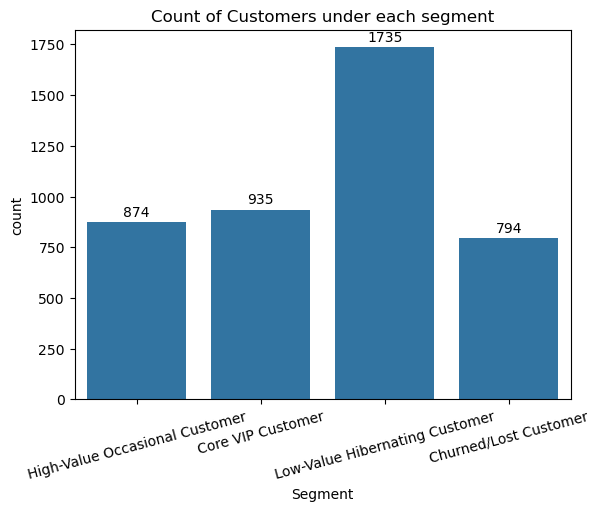

In [17]:
## Data Visualization

# Visualized customer segments, purchasing behavior, and demographic distribution using 
# count plots, scatter plots, and heatmaps.

ax = sns.countplot(
    x='Segment',
    data=customer_df
)
plt.xticks(rotation=15)
ax.bar_label(ax.containers[0], padding=2)
print('Total Number of Customers:', customer_df['CustomerID'].nunique())
plt.title('Count of Customers under each segment')
plt.show()

In [18]:
# Cluster 0: Churned / Lost Customers 
# Minimal value and highly inactive. They placed roughly one order, spent very little ($183), and haven't returned in nearly 6 months (168.2 days).
# Strategy: Low-cost automated win-back triggers. Better to focus on Clusters 1 and 2 instead of overspending marketing budget here.

# Cluster 1: High-Value Occasional Customers
# Solid spenders but less frequent. They generate good revenue ($2,234) and moderate orders (2.7), but haven't bought in a couple of months (85.4 days).
# Strategy: Cross-selling, personalized recommendations, and targeted incentives to increase buying frequency.

# Cluster 2: Core VIP Customers
# Exceptional loyalty and spending. They have the lowest recency (15.9 days) and by far the highest frequency (11.9 orders) and revenue ($6,282).
# Strategy: High-touch retention, exclusive rewards, and VIP loyalty perks.

# Cluster 3: Low-Value Hibernating Customers
# Low spend and frequency, lagging activity. They have low orders (2.1), lower spending ($527), and haven't interacted in over 3 months (100.2 days).
# Strategy: Email re-engagement campaigns, special discount offers, and "We Miss You" bundles.

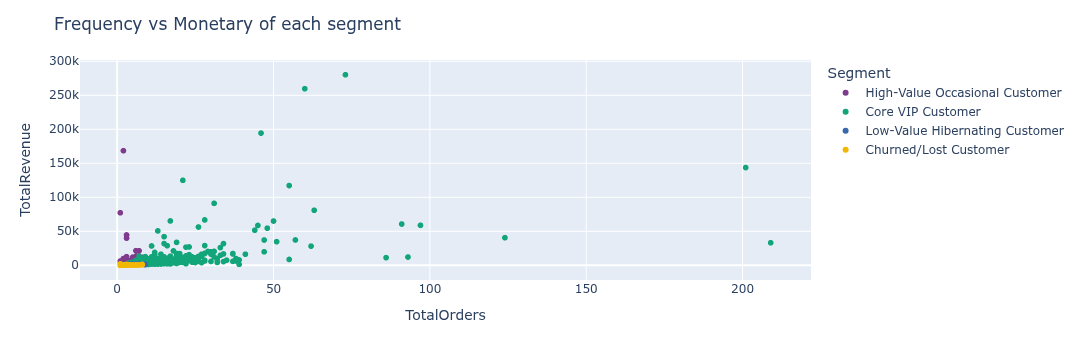

In [19]:
fig = px.scatter(
    customer_df,
    x='TotalOrders',
    y='TotalRevenue',
    color='Segment',
    hover_data=['Country'],
    color_discrete_sequence=px.colors.qualitative.Bold
)
fig.update_layout(title='Frequency vs Monetary of each segment')
fig.show()

In [20]:
country_segment = pd.crosstab(
    customer_df['Country'],
    customer_df['Segment']
)

print(country_segment)

Segment               Churned/Lost Customer  Core VIP Customer  \
Country                                                          
Australia                                 1                  3   
Austria                                   1                  0   
Bahrain                                   1                  0   
Belgium                                   4                  5   
Brazil                                    0                  0   
Canada                                    2                  0   
Channel Islands                           0                  2   
Cyprus                                    1                  0   
Czech Republic                            0                  0   
Denmark                                   0                  0   
EIRE                                      0                  2   
European Community                        0                  0   
Finland                                   2                  3   
France    

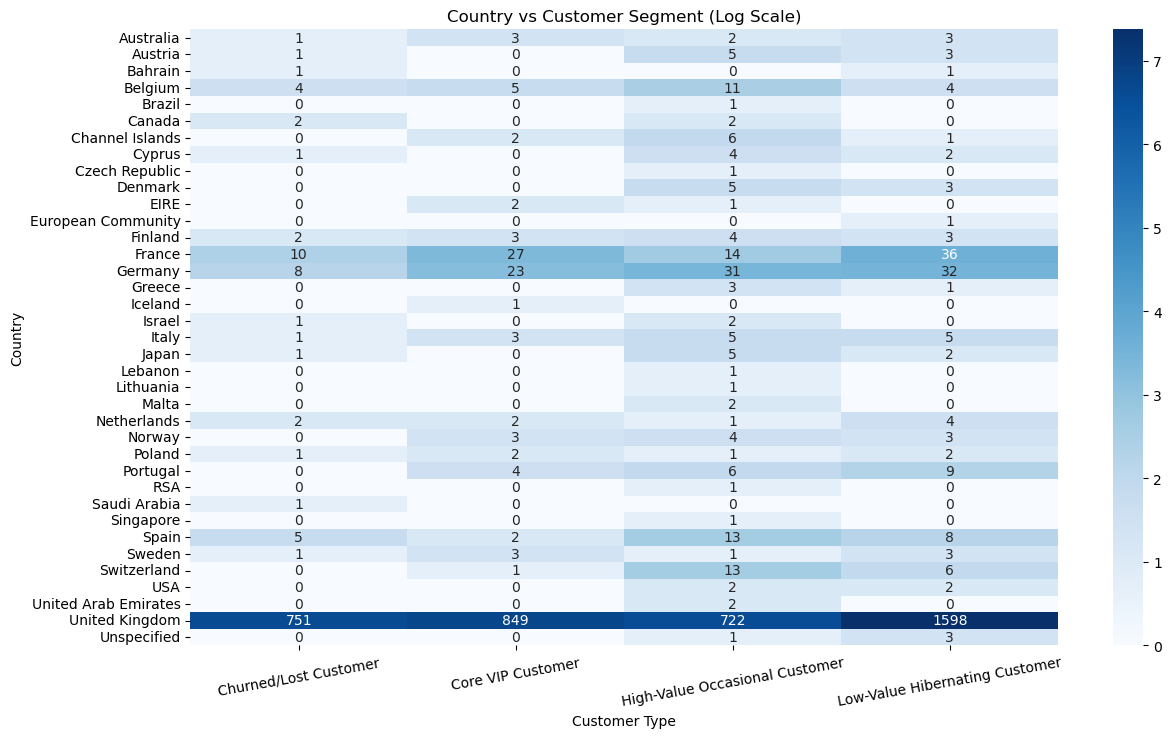

In [29]:
plt.figure(figsize=(14,8))

sns.heatmap(
    np.log1p(country_segment),
    annot=country_segment,
    fmt='d',
    cmap='Blues'
)

plt.title('Country vs Customer Segment (Log Scale)')
plt.xlabel('Customer Type')
plt.ylabel('Country')
plt.xticks(rotation=10)
plt.show()

In [22]:
# Conclusion:
# The project successfully segmented customers into four distinct groups using RFM-based behavioral analysis
# and KMeans clustering. The segmentation identified VIP, premium, regular active, and inactive low-value customers
# based on purchasing behavior, spending patterns, and recency. These insights can help businesses improve customer retention, 
# targeted marketing, and strategic decision-making.